<a href="https://colab.research.google.com/github/ICam99/roboticaMovil/blob/main/Tarea5_IgnacioC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

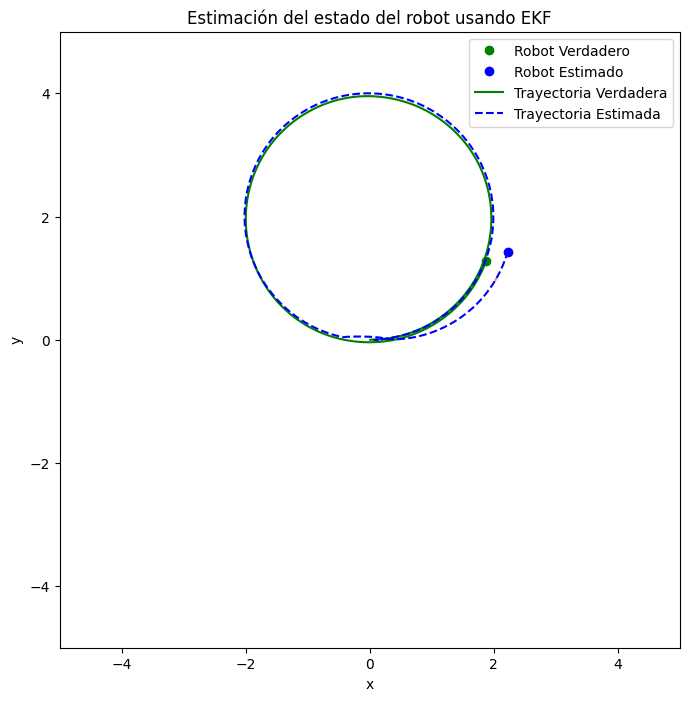

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Ellipse
from IPython.display import HTML

# Parámetros del sistema
dt = 0.01  # Paso de tiempo
v = 1.0    # Velocidad lineal (control)
omega = 0.5  # Velocidad angular (control)

# Ruido en los controles
sigma_v = 0.1  # Desviación estándar del ruido en la velocidad lineal
sigma_omega = 0.05  # Desviación estándar del ruido en la velocidad angular

# Ruido en las mediciones
sigma_r = 0.1  # Desviación estándar del ruido en la distancia
sigma_phi = 0.05  # Desviación estándar del ruido en el ángulo

# Estado inicial del robot
X_true = np.array([0.0, 0.0, 0.0, v, omega])  # [x, y, theta, v, omega]
X_est = np.array([0.0, 0.0, 0.0, v, omega])  # Estimación inicial
P_est = np.eye(5)  # Matriz de covarianza inicial

# Matrices de ruido
# Matriz de ruido del proceso Q (5x5)
Q = np.zeros((5, 5))  # Inicializar con ceros
Q[3, 3] = sigma_v**2  # Ruido en la velocidad lineal v
Q[4, 4] = sigma_omega**2  # Ruido en la velocidad angular omega
R = np.diag([sigma_r**2, sigma_phi**2])  # Ruido en las mediciones

# Función de transición de estado
def state_transition(X, v, omega, dt):
    x, y, theta, _, _ = X
    x_new = x + v * np.cos(theta) * dt
    y_new = y + v * np.sin(theta) * dt
    theta_new = theta + omega * dt
    return np.array([x_new, y_new, theta_new, v, omega])

# Función de observación
def observation_model(X):
    x, y, _, _, _ = X
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return np.array([r, phi])

# Jacobiano de la función de transición
def jacobian_F(X, v, omega, dt):
    x, y, theta, _, _ = X
    F = np.eye(5)
    F[0, 2] = -v * np.sin(theta) * dt
    F[1, 2] = v * np.cos(theta) * dt
    return F

# Jacobiano de la función de observación
def jacobian_H(X):
    x, y, _, _, _ = X
    r = np.sqrt(x**2 + y**2)
    H = np.zeros((2, 5))
    H[0, 0] = x / r
    H[0, 1] = y / r
    H[1, 0] = -y / (x**2 + y**2)
    H[1, 1] = x / (x**2 + y**2)
    return H

# Función para dibujar elipses de covarianza
def plot_ellipse(ax, mean, cov, color='r', n_std=2):
    eigvals, eigvecs = np.linalg.eigh(cov[:2, :2])
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigvals)
    ellipse = Ellipse(mean[:2], width, height, angle=angle, edgecolor=color, facecolor='none')
    ax.add_patch(ellipse)

# Simulación (combinando la lógica de ambas celdas)
num_steps = 1500
X_true_history = np.zeros((num_steps, 5))
X_est_history = np.zeros((num_steps, 5))
P_history = np.zeros((num_steps, 5, 5))

for t in range(num_steps):
    # Ruido en los controles
    v_noisy = v + np.random.normal(0, sigma_v)
    omega_noisy = omega + np.random.normal(0, sigma_omega)

    # Actualización del estado verdadero (con ruido)
    X_true = state_transition(X_true, v_noisy, omega_noisy, dt)

    # Predicción del EKF
    X_pred = state_transition(X_est, v, omega, dt)
    F = jacobian_F(X_est, v, omega, dt)
    P_pred = F @ P_est @ F.T + Q

    # Medición (con ruido)
    z_true = observation_model(X_true)
    z_noisy = z_true + np.random.normal(0, [sigma_r, sigma_phi])

    # Corrección del EKF
    H = jacobian_H(X_pred)
    y = z_noisy - observation_model(X_pred)
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    X_est = X_pred + K @ y
    P_est = (np.eye(5) - K @ H) @ P_pred

    # Guardar historial
    X_true_history[t] = X_true
    X_est_history[t] = X_est
    P_history[t] = P_est

# Animación
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Estimación del estado del robot usando EKF')

# Inicializar elementos de la animación
point_true, = ax.plot([], [], 'go', label='Robot Verdadero') # Robot verdadero en verde
point_est, = ax.plot([], [], 'bo', label='Robot Estimado')  # Robot estimado en azul
line_true, = ax.plot([], [], 'g-', label='Trayectoria Verdadera')
line_est, = ax.plot([], [], 'b--', label='Trayectoria Estimada')
ellipse = Ellipse(xy=(0, 0), width=0, height=0, angle=0, edgecolor='r', facecolor='none') # Elipse inicial
ax.add_patch(ellipse)

ax.legend()  # Mostrar leyenda

# Función de inicialización
def init():
    point_true.set_data([], [])
    point_est.set_data([], [])
    line_true.set_data([], [])
    line_est.set_data([], [])
    ellipse.set_visible(False)  # Ocultar la elipse inicial
    return point_true, point_est, line_true, line_est, ellipse

# Función de actualización
def update(frame):
    # Actualizar posiciones y trayectorias
    point_true.set_data([X_true_history[frame, 0]], [X_true_history[frame, 1]])
    point_est.set_data([X_est_history[frame, 0]], [X_est_history[frame, 1]])
    line_true.set_data(X_true_history[:frame, 0], X_true_history[:frame, 1])
    line_est.set_data(X_est_history[:frame, 0], X_est_history[:frame, 1])

    # Actualizar la elipse de covarianza (cada 50 pasos)
    if frame % 50 == 0:
        mean = X_est_history[frame, :2]
        cov = P_history[frame, :2, :2]
        eigvals, eigvecs = np.linalg.eigh(cov)
        angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
        width, height = 2 * 2 * np.sqrt(eigvals)  # 2 desviaciones estándar
        ellipse.set_center(mean)
        ellipse.set_width(width)
        ellipse.set_height(height)
        ellipse.set_angle(angle)
        ellipse.set_visible(True)

    return point_true, point_est, line_true, line_est, ellipse

# Crear y mostrar la animación
ani = FuncAnimation(fig, update, frames=num_steps, init_func=init, blit=True, interval=10)
HTML(ani.to_html5_video())